> ### Public copy — demo data
>
> The 2024 survey this project was built on belongs to the client and is not redistributable, so
> it is **not in this repository**. In its place, `data/raw/engagement_survey_2024.xlsx` is written
> by `scripts/make_demo_workbook.py`: the same sheet name, the same 22 columns and 42 rows, the
> same category headers, the same two 1-10 items and the same delta-from-company-mean encoding —
> and **entirely invented numbers**.
>
> So: the code, the method choices and the reasoning below are the originals. Every number, table
> and chart is computed from demo data, and every Phase 1 figure is badged **DEMO** instead of
> REAL. Where a passage describes what was actually found on the client's data it says so and
> points to the section of the accompanying report that carries the figures.
>
> `data.provenance` in `config/config.yaml` is the switch: set it to `real` once the client
> workbook is in place, and the badges change back.

# 06 — Phase 3: Comparing two Phases

|  |  |
|---|---|
| **Purpose** | Set what Phase 1 could answer against what Phase 2 unlocked, and convert the gap into the 2026 instrument and a priority map (RO4). |
| **Input** | Phase 1 survey results + Phase 2 demonstration results |
| **Outputs** | `tab20`–`tab23` · `fig09` |
| **Evidence for essay** | §5.1 → **Appendix D4** = `tab20` · §5.2 → **Figure 14** = `fig09` (+ `tab21`) · §6.3 → **Table 5** = `tab22` · §6.1 → `tab23` |
| **Objectives** | RO4 |

> **Claim boundary.** The two axes have different provenance: **performance** comes from the
> survey workbook (Phase 1), **importance** from the synthetic demonstration (Phase 2). They are
> combined only to *prioritise*, never to assert new facts about a workforce. In this public copy
> the performance side is computed from the demo workbook — see the banner above.

In [1]:
# Environment setup
import sys
sys.path.insert(0, "../src")

import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul.*",
                        category=RuntimeWarning)  # spurious BLAS warning; see NB03

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from engagement import io, quality, phase1, models, synthesis, viz
from engagement.config import load_config

cfg = load_config()
pd.set_option("display.max_colwidth", 110)

---
## A. The capability comparison · essay §5.1

**Decision box**

| | |
|---|---|
| **What** | One row per client question: what Phase 1 could do, what Phase 2 added, and the specific missing data element that made the difference. |
| **Why written as code, not prose** | The table is the evidence base every 2026 recommendation traces back to. Generating it beside the results keeps it from drifting out of step with them, and it is cited once rather than restated in each notebook. |
| **Feeds** | `tab20` → essay §5.1 (**Appendix D4**). |

In [2]:
comparison = synthesis.capability_comparison()
comparison

,Phase 1 (real 2024 data),Phase 2 (synthetic demonstration),missing data element -> 2026
client question,,,
What drives engagement? (O2),"Prohibited: aggregated means, no outcome variable","Ranked, VIF-checked, triangulated driver table (tab16)",Individual responses + UWES outcome block
Who is at risk? (O3),"Department-level screening only (9 items flagged, tab06)","Individual risk scores, temporally validated, explainable (tab17-18)",Individual responses + demographics
Are the scales sound?,Untestable (no item-level data); scale-mixing defect found (tab01),Alpha per construct; short-scale weakness exposed (tab15),Item-level responses
Are there segments? (O1/O3),"No archetypes recoverable (silhouette < 0.25, NB03)",Persona machinery with risk & demographic profiles (tab19),Demographics + department sizes
Is engagement moving? (O1),Single 2024 snapshot,Wave trajectories (fig08),"Multi-wave collection, comparable instrument"


**Read:** each gap is traceable to a missing data *element*, not to a limitation of method, which
is what makes the 2026 recommendation a consequence rather than a preference.

---
## B. Importance x performance, where to act · essay §5.2

**Decision box**

| | |
|---|---|
| **What** | Phase 2 driver importance (relative weights, tab16) against Phase 1 survey performance (corrected theme means, tab03), with the weakest item of each theme plotted beside its mean. |
| **Why the weakest item too** | A theme mean averages a whole block, and a theme can sit comfortably above the midpoint while its weakest question sits well below its own mean. The mean hides exactly the item an intervention would target, so both are plotted. |
| **Why the split panel** | Constructs the 2024 survey never measured have no performance value at all. They cannot be placed on the 2x2, and that absence is the headline, so they are shown rather than dropped. |
| **Feeds** | `tab21`, `fig09` → essay §5.2 (**Figure 14**). |

In [3]:
# recompute the two inputs from source (same functions the pipeline uses)
tidy = io.tidy(io.load_heatmap(cfg), cfg)
harmonised = quality.harmonise_scales(quality.reconstruct_absolute(tidy), cfg)
theme_means = phase1.theme_ranking(harmonised)["mean"]

data = pd.read_csv("../data/synthetic/synthetic_panel.csv")
item_map = pd.read_csv("../data/synthetic/synthetic_item_map.csv", index_col=0)
model_df = models.prepare(data, item_map, cfg)
drivers = models.driver_analysis(model_df[model_df["wave"] == 1])

ip = synthesis.importance_performance(drivers, theme_means,
                                      phase1.dispersion_screen(harmonised, cfg))

a = ip.attrs
print(f"importance measured by the 2024 survey : "
      f"{ip.loc[ip['measured_2024'], 'importance_%'].sum():.1f}%")
print(f"importance NOT measured in 2024        : "
      f"{ip.loc[~ip['measured_2024'], 'importance_%'].sum():.1f}%")
print(f"importance/performance rank alignment  : rho = {a['rank_alignment_spearman']}")
print(f"IMPROVE cell empty by construction     : {a['improve_cell_empty_by_construction']}")
print(f"performance axis span                  : {a['performance_span']} of a scale point")
print(f"priority items inside PROTECT themes   : "
      f"{int(ip.loc[ip['quadrant'].str.startswith('PROTECT'), 'n_priority_items'].sum())} of 9")

ip

importance measured by the 2024 survey : 55.4%
importance NOT measured in 2024        : 44.6%
importance/performance rank alignment  : rho = 0.8
IMPROVE cell empty by construction     : True
performance axis span                  : 0.797 of a scale point
priority items inside PROTECT themes   : 1 of 9


,importance_%,performance_2024,measured_2024,n_priority_items,weakest_item_score,weakest_item,quadrant
construct,,,,,,,
development,24.1,3.823,True,0.0,3.65,I believe I have an equal opportunity within the team to have a stable,"PROTECT (high importance, high performance)"
personal,23.8,NaN,False,NaN,NaN,,MEASURE FIRST (not in 2024 survey)
social,21.0,3.965,True,1.0,3.60,I feel comfortable sharing my ideas at work with peers and management.,"PROTECT (high importance, high performance)"
psych_safety,9.0,NaN,False,NaN,NaN,,MEASURE FIRST (not in 2024 survey)
technology,7.8,NaN,False,NaN,NaN,,MEASURE FIRST (not in 2024 survey)
balance,6.2,3.640,True,2.0,3.43,I feel the amount of work assigned to me is manageable,"MONITOR (low importance, low performance)"
justice,4.1,3.168,True,6.0,3.05,I trust the Executive team to lead the business to success.,"MONITOR (low importance, low performance)"
esg,4.0,NaN,False,NaN,NaN,,MEASURE FIRST (not in 2024 survey)


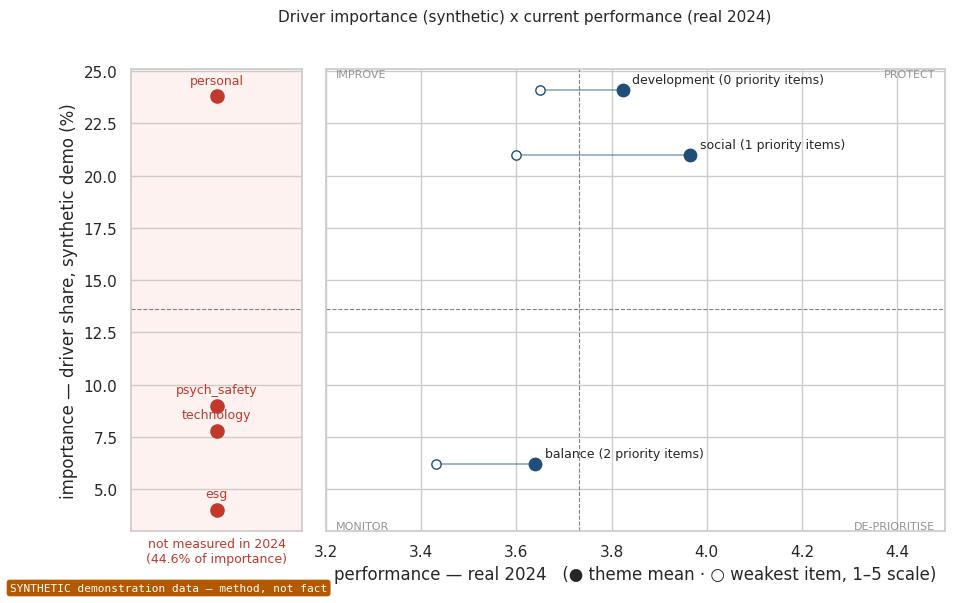

In [4]:
m = ip[ip["measured_2024"]].copy()
u = ip[~ip["measured_2024"]].copy()
imp_med, perf_med = m["importance_%"].median(), m["performance_2024"].median()

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10.5, 6), sharey=True,
                               gridspec_kw={"width_ratios": [1, 3.6], "wspace": 0.06})

# left: the constructs 2024 cannot place at all
axL.set_facecolor("#fdf2f0")
axL.scatter(np.zeros(len(u)), u["importance_%"], s=90, color="#c0392b", zorder=3)
for con, r in u.iterrows():
    axL.annotate(con, (0, r["importance_%"]), xytext=(0, 9), ha="center",
                 textcoords="offset points", fontsize=9, color="#c0392b")
axL.axhline(imp_med, c="grey", lw=0.8, ls="--")
axL.set_xlim(-0.5, 0.5); axL.set_xticks([])
axL.set_xlabel(f"not measured in 2024\n({u['importance_%'].sum():.1f}% of importance)",
               fontsize=9, color="#c0392b")
axL.set_ylabel("importance — driver share, synthetic demo (%)")

# right: the 2x2, with each construct drawn from weakest item to theme mean
axR.axhline(imp_med, c="grey", lw=0.8, ls="--")
axR.axvline(perf_med, c="grey", lw=0.8, ls="--")
for con, r in m.iterrows():
    axR.plot([r["weakest_item_score"], r["performance_2024"]],
             [r["importance_%"]] * 2, color="#1f4e79", lw=1.3, alpha=0.45, zorder=2)
    axR.scatter(r["weakest_item_score"], r["importance_%"], s=45,
                facecolor="white", edgecolor="#1f4e79", zorder=3)
    axR.annotate(f"{con} ({int(r['n_priority_items'])} priority items)",
                 (r["performance_2024"], r["importance_%"]),
                 xytext=(7, 5), textcoords="offset points", fontsize=9)
axR.scatter(m["performance_2024"], m["importance_%"], s=80, color="#1f4e79", zorder=4)
axR.set_xlim(3.2, 4.5)
axR.set_xlabel("performance — real 2024   (● theme mean · ○ weakest item, 1–5 scale)")

lo, hi = axR.get_ylim()
for x, y, t, ha, va in [(3.22, hi, "IMPROVE", "left", "top"),
                        (4.48, hi, "PROTECT", "right", "top"),
                        (3.22, lo, "MONITOR", "left", "bottom"),
                        (4.48, lo, "DE-PRIORITISE", "right", "bottom")]:
    axR.text(x, y, t, fontsize=8, color="grey", ha=ha, va=va, alpha=0.85)

fig.suptitle("Driver importance (synthetic) × current performance (real 2024)", fontsize=12)
viz.save_figure(fig, "fig09_importance_performance", cfg, "synthetic",
                "Driver importance (synthetic) x current performance (real 2024)")
plt.show()

**Read (essay §5.2).** Three results, in order of importance:

1. **The survey is incomplete, not broken.** The constructs the 2024 instrument already measures
   carry roughly half of total driver importance; the four it never measured — personal resources,
   psychological safety, technology, ESG — carry the other half. Half the explanatory weight sitting
   outside the instrument is what decides the shape of the recommendation: the instrument needs
   *extending*, not replacing. Note also that the unmeasured constructs cannot be placed on the
   performance axis at all, so they are invisible to any prioritisation built on the 2024 survey
   alone — an absence that is itself the argument.
2. **The IMPROVE cell is empty by arithmetic, not by luck.** Across the measured constructs,
   importance and performance rank almost identically and performance spans a fraction of a scale
   point, so the high-importance and low-performance sets cannot overlap. Reported as a property
   of the map rather than presented as good news — an empty quadrant forced by the geometry of the
   data is not evidence that nothing needs improving.
3. **Theme means conceal.** A theme can read PROTECT at theme level while owning several of the
   priority *items* from §3.3, because its weakest question scores well below its own mean. This is
   the §3.3 dispersion argument arriving a second time by a different route.

Note this **disagrees with the §3.5 IPMA** on the client data, and the disagreement is reported
rather than quietly reconciled: §3.5 importance is bivariate across ~19 departments and carries the
§3.4 halo, whereas relative weights here control for competing predictors. Two proxies at two
levels of aggregation should not be expected to agree, and saying so is part of the result.
Figures are in §5.2 of the accompanying report.

---
## C. The 2026 instrument (keep / add / drop / fix) · essay §6.3

**Decision box**

| | |
|---|---|
| **What** | Eleven decisions, each with a one-line justification traced to a specific analytical result (tabNN / notebook) or literature factor. |
| **Why this form** | The client asked for an evidence-based, streamlined survey. A recommendation without its trace is an opinion; the traced column is what makes it auditable. |
| **Feeds** | `tab22` → essay §6.3 (**Table 5**). |

In [5]:
redesign = synthesis.survey_redesign()
redesign

,decision,element,justification (traced)
0,KEEP,Manager / team / leadership relationship blocks,Strong social-resource coverage; aligns with Saks (2006); Phase 1 shows these are the company's strengths ...
1,KEEP,eNPS / recommendation and retention items,"Comparable outcome anchors across waves (used as IPMA anchors, tab09)"
2,ADD,UWES-9 engagement block (vigour / dedication / absorption),No direct outcome existed; precondition for any driver or risk model (Schaufeli & Bakker 2004; demonstrate...
3,ADD,Personal-resources scale (>=4 items),"Strongest meta-analytic correlate (r=.48, Mazzetti 2021) and TOP-ranked driver in the demonstration — enti..."
4,ADD,Technology & work-mode items + work-mode field,Distinct driver for distributed teams (Choudhary & Jain 2024); demonstrated importance in tab16
5,ADD,Psychological-safety and justice scales (>=4 items each),"Block length drives reliability: 2-item blocks reached alpha .62 and 3-item blocks only .686-.747 in NB05,..."
6,ADD,ESG-alignment items,Emerging fintech-relevant lever (Gannon & Hieker 2022)
7,ADD,"Demographics: region, tenure, role level, work mode, department size",Required for the segmentation/risk objectives; dept sizes unknown even at aggregate level in 2024 (tab10 n...
8,DROP/MERGE,Redundant sentiment items within 'Working for AccessFintech',"Outcome-adjacent block (IPMA circularity, tab09); UWES replaces its measurement role:keep eNPS, merge the ..."
9,FIX,Single 1-5 scale for every item,Mixed 1-5/1-10 scales corrupted the workbook's own roll-ups (tab01) and echoed into correlations (NB02)


**Read:** the balance is six ADDs against one DROP, consistent with panel 1 above. The two FIX
rows (one 1–5 scale; item-level multi-wave storage) cost nothing to implement and are what
unblocked every analysis Phase 1 could not run.

---
## D. Traceability

Closing audit: every deliverable maps to a refined objective and back to the client's brief.
Nothing produced without a purpose, no objective left without evidence.

In [6]:
trace = synthesis.traceability()
trace

,deliverable,refined objective,client objective
0,"Corrected theme ranking + department benchmark (tab03-04, fig01-02)",RO1,O1
1,"Priority-risk screen, localised vs company-wide (tab06)",RO3a,O3
2,"One-dimension (halo) finding, 3 converging analyses (NB02-03)",RO1,O1
3,"Calibrated synthetic panel + two quality gates (tab13-14, fig05)",RO2 prep,O2
4,"Ranked driver table, triangulated (tab16, fig06)",RO2,O2
5,"Temporally-validated risk model + explanations (tab17-18, fig07)",RO3b,O3
6,Persona machinery + honest structure verdict (tab19),RO3b,O3
7,"Importance x performance priorities (tab21, fig09)",RO4,O4
8,Keep/add/drop/fix 2026 instrument (tab22),RO4,O4


In [7]:
from pathlib import Path
t = Path(cfg["paths"]["tables_dir"]); t.mkdir(parents=True, exist_ok=True)
comparison.to_csv(t / "tab20_capability_comparison.csv")
ip.to_csv(t / "tab21_importance_performance.csv")
redesign.to_csv(t / "tab22_survey_redesign.csv", index=False)
trace.to_csv(t / "tab23_traceability.csv", index=False)
print("tables tab20–tab23 written")

tables tab20–tab23 written


---
## Closing

Phase 1 measured, rather than assumed, what the 2024 data cannot answer. Phase 2 demonstrated on
calibrated synthetic data that the machinery delivers once fit-for-purpose data exists. Phase 3
converted that measured gap into an instrument (`tab22`) and a priority map (`fig09`) whose most
important entry is the one the current survey cannot see.

The recommendation to redesign the 2026 survey is a traceable consequence of notebooks 01–05, not
a preference.